In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile

zip_path = '/content/drive/MyDrive/fraudTest.csv.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("unzipped_data")


In [12]:
import os

extracted_files = os.listdir("unzipped_data")
print(extracted_files)

['fraudTest.csv']


In [13]:
import pandas as pd

csv_path = '/content/unzipped_data/fraudTest.csv'
df = pd.read_csv(csv_path)
df.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

In [15]:
import pandas as pd

# Load your dataset
df = pd.read_csv("/content/drive/MyDrive/fraudTest.csv.zip")

# Preview
print(df.head())
print(df.info())
print(df.describe())


   Unnamed: 0 trans_date_trans_time            cc_num  \
0           0   2020-06-21 12:14:25  2291163933867244   
1           1   2020-06-21 12:14:33  3573030041201292   
2           2   2020-06-21 12:14:53  3598215285024754   
3           3   2020-06-21 12:15:15  3591919803438423   
4           4   2020-06-21 12:15:17  3526826139003047   

                               merchant        category    amt   first  \
0                 fraud_Kirlin and Sons   personal_care   2.86    Jeff   
1                  fraud_Sporer-Keebler   personal_care  29.84  Joanne   
2  fraud_Swaniawski, Nitzsche and Welch  health_fitness  41.28  Ashley   
3                     fraud_Haley Group        misc_pos  60.05   Brian   
4                 fraud_Johnston-Casper          travel   3.19  Nathan   

       last gender                       street  ...      lat      long  \
0   Elliott      M            351 Darlene Green  ...  33.9659  -80.9355   
1  Williams      F             3638 Marsh Union  ...  40.3207 

In [16]:
df['is_fraud'].value_counts(normalize=True)


,proportion
is_fraud,
0,0.99614
1,0.00386


In [17]:
import pandas as pd

# Assuming df is already loaded
skew_amt = df['amt'].skew()
print(f"Skewness of 'amt': {skew_amt:.2f}")


Skewness of 'amt': 37.13


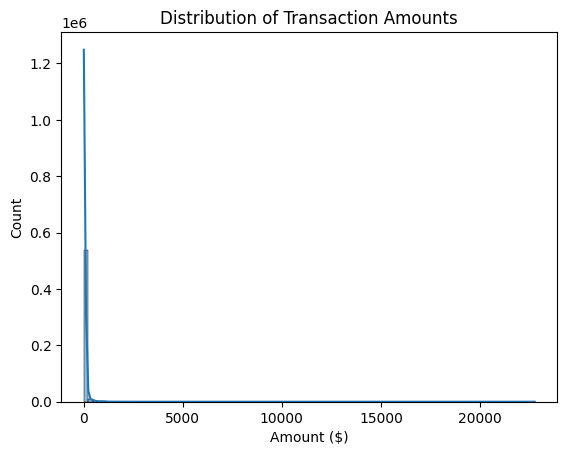

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['amt'], bins=100, kde=True)
plt.title("Distribution of Transaction Amounts")
plt.xlabel("Amount ($)")
plt.show()


<Axes: xlabel='log_amt', ylabel='Count'>

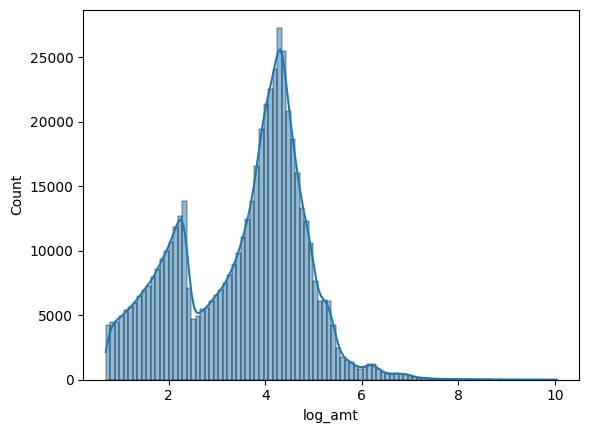

In [19]:
# Check skewness
import numpy as np
df['amt'].skew()

# Try transformation
df['log_amt'] = np.log1p(df['amt'])

# Visualize effect
sns.histplot(df['log_amt'], bins=100, kde=True)


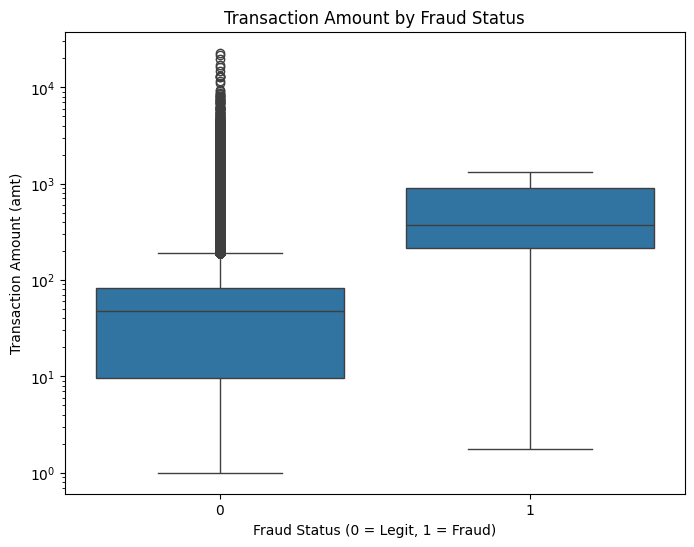

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)

plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Status (0 = Legit, 1 = Fraud)')
plt.ylabel('Transaction Amount (amt)')
plt.yscale('log')  # Optional: Apply log scale to y-axis for better visibility
plt.show()


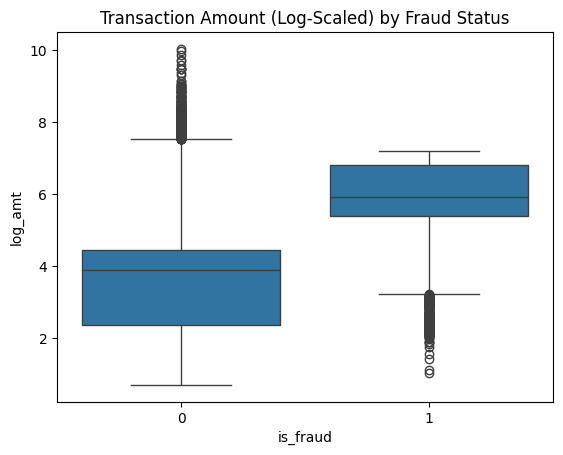

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x='is_fraud', y='log_amt')
plt.title('Transaction Amount (Log-Scaled) by Fraud Status')
plt.show()


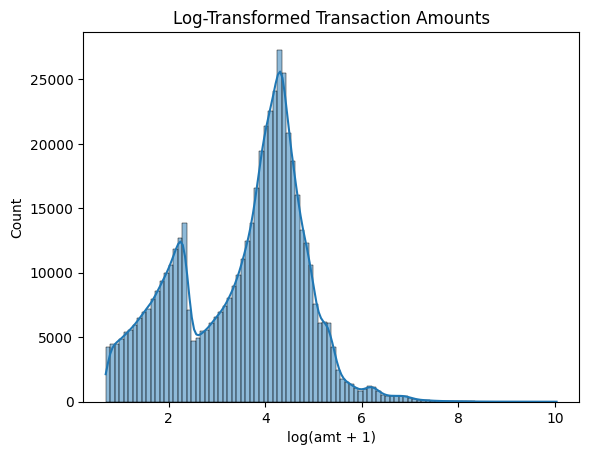

In [22]:
import numpy as np  # Make sure this is here

# Apply log transformation
df['log_amt'] = np.log1p(df['amt'])

# Optional: Visualize the new distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['log_amt'], bins=100, kde=True)
plt.title("Log-Transformed Transaction Amounts")
plt.xlabel("log(amt + 1)")
plt.show()


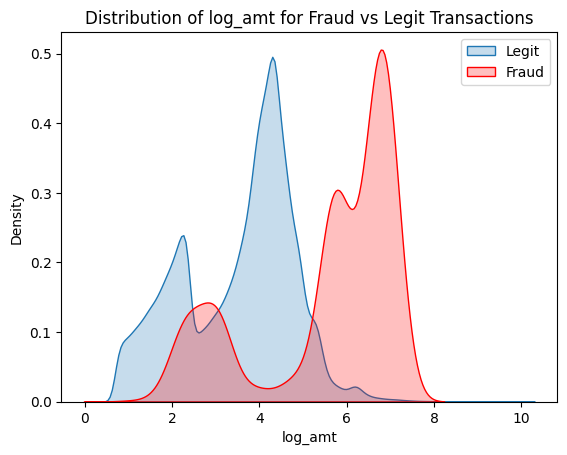

In [32]:
sns.kdeplot(data=df[df['is_fraud'] == 0]['log_amt'], label='Legit', fill=True)
sns.kdeplot(data=df[df['is_fraud'] == 1]['log_amt'], label='Fraud', fill=True, color='red')
plt.title("Distribution of log_amt for Fraud vs Legit Transactions")
plt.legend()
plt.show()


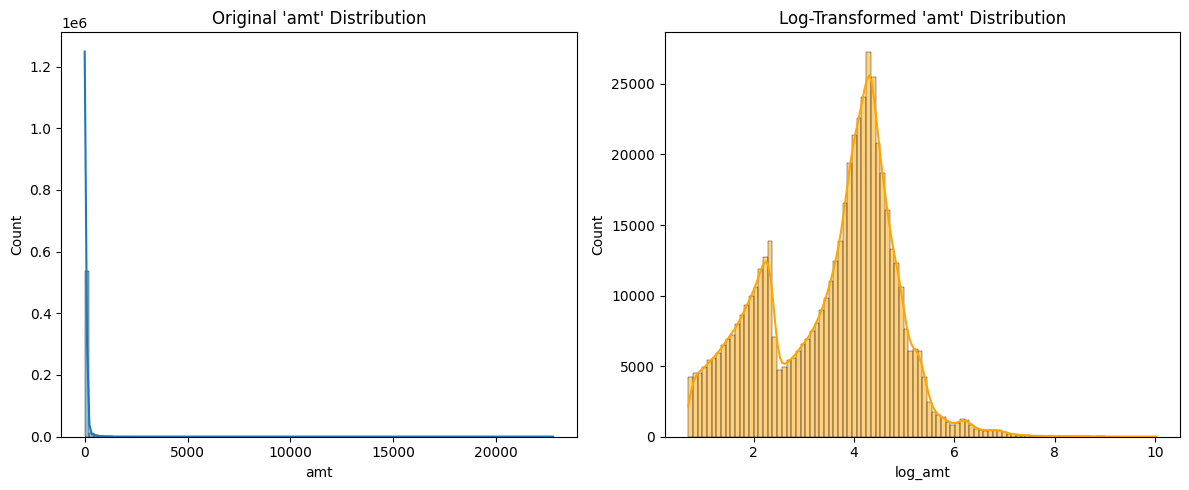

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# Original
plt.subplot(1, 2, 1)
sns.histplot(df['amt'], bins=100, kde=True)
plt.title("Original 'amt' Distribution")

# Transformed
plt.subplot(1, 2, 2)
sns.histplot(df['log_amt'], bins=100, kde=True, color='orange')
plt.title("Log-Transformed 'amt' Distribution")

plt.tight_layout()
plt.show()


In [24]:
import numpy as np
import pandas as pd

# Original skewness
original_skew = df['amt'].skew()
print(f"Original 'amt' skewness: {original_skew:.2f}")

# Log transform (if not already done)
df['log_amt'] = np.log1p(df['amt'])

# Transformed skewness
log_skew = df['log_amt'].skew()
print(f"Log-transformed 'amt' skewness: {log_skew:.2f}")


Original 'amt' skewness: 37.13
Log-transformed 'amt' skewness: -0.31


In [25]:
# Skewness of city_pop
city_pop_skew = df['city_pop'].skew()
print(f"Skewness of 'city_pop': {city_pop_skew:.2f}")


Skewness of 'city_pop': 5.58


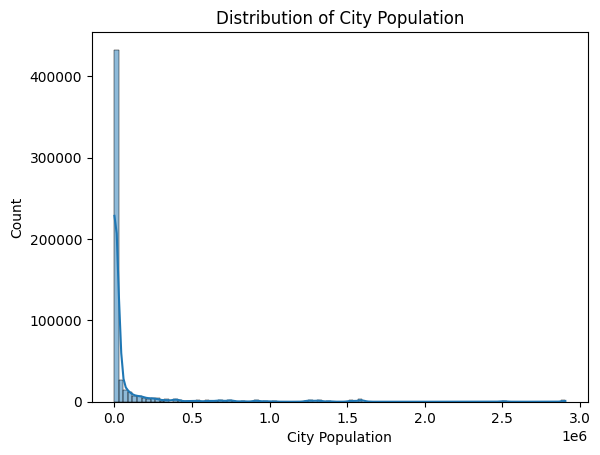

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['city_pop'], bins=100, kde=True)
plt.title("Distribution of City Population")
plt.xlabel("City Population")
plt.show()


In [27]:
df['log_city_pop'] = np.log1p(df['city_pop'])
print(f"Skewness of 'log_city_pop': {df['log_city_pop'].skew():.2f}")


Skewness of 'log_city_pop': 0.61


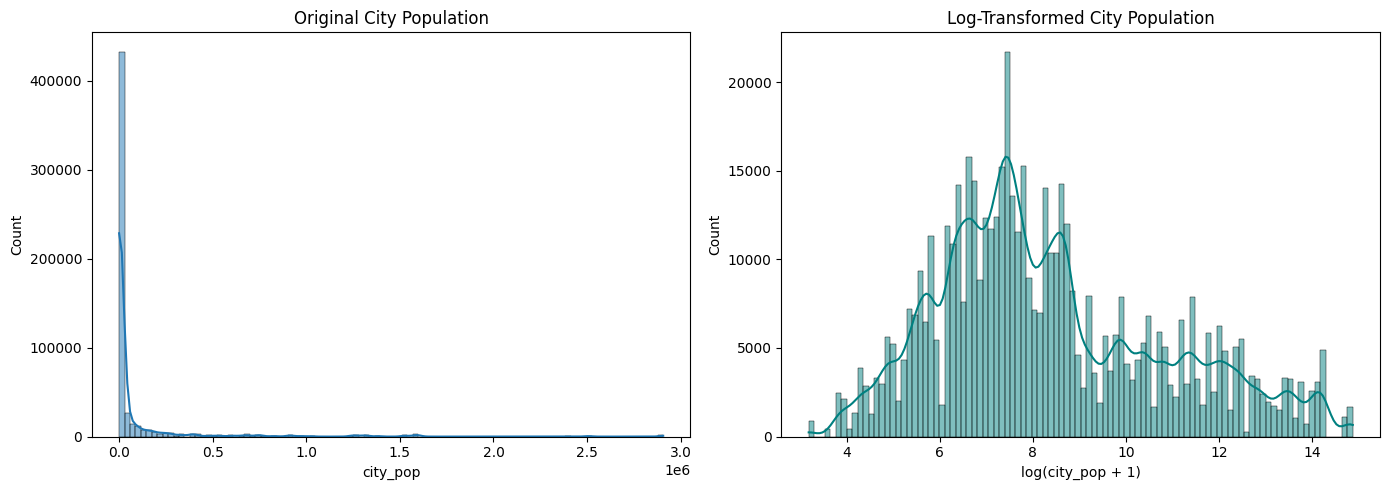

In [28]:
plt.figure(figsize=(14, 5))

# Original
plt.subplot(1, 2, 1)
sns.histplot(df['city_pop'], bins=100, kde=True)
plt.title("Original City Population")
plt.xlabel("city_pop")

# Transformed
plt.subplot(1, 2, 2)
sns.histplot(df['log_city_pop'], bins=100, kde=True, color='teal')
plt.title("Log-Transformed City Population")
plt.xlabel("log(city_pop + 1)")

plt.tight_layout()
plt.show()


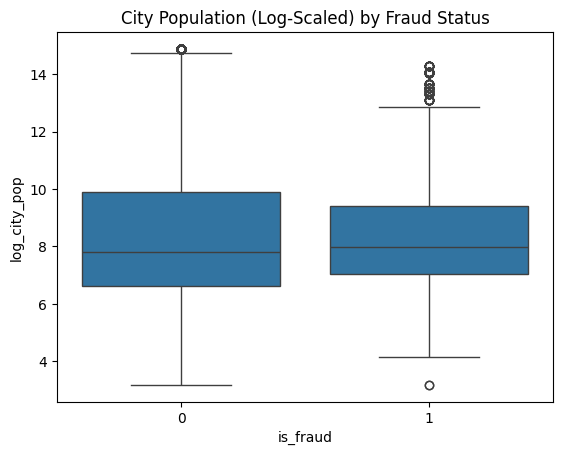

In [29]:
sns.boxplot(data=df, x='is_fraud', y='log_city_pop')
plt.title('City Population (Log-Scaled) by Fraud Status')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


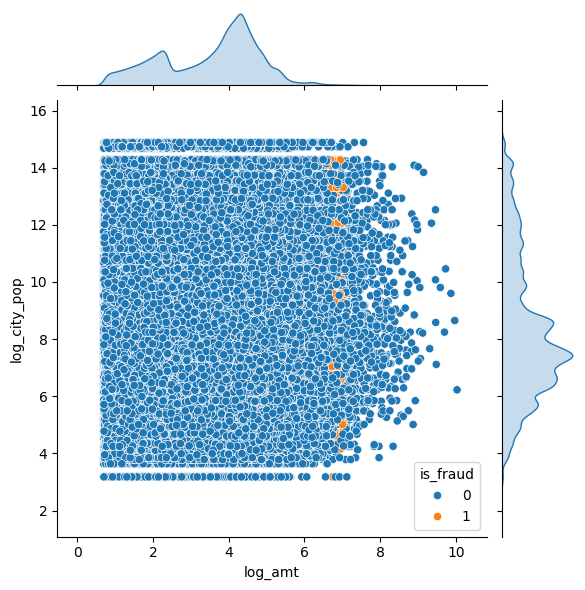

In [30]:
sns.jointplot(data=df, x='log_amt', y='log_city_pop', hue='is_fraud', kind='scatter')


In [31]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud', 'log_amt', 'log_city_pop'],
      dtype='object')

In [33]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,log_amt,log_city_pop
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,1.350667,12.717392
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,3.428813,5.713733
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,3.744314,10.448628
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,4.111693,10.910861
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,1.432701,7.027315


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

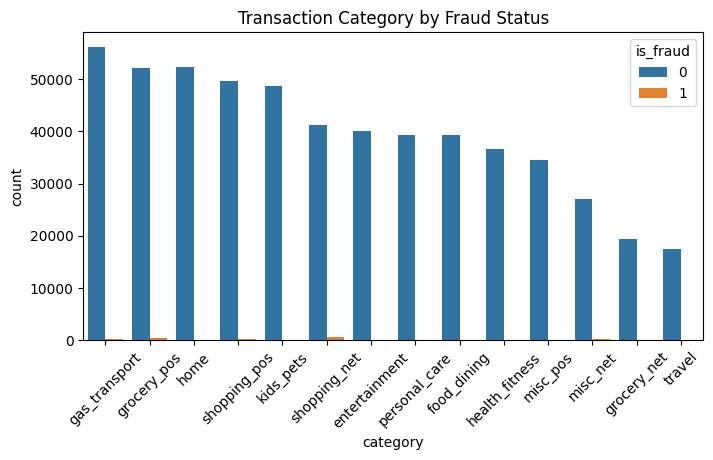

In [38]:
plt.figure(figsize=(8, 4))
sns.countplot(x='category', hue='is_fraud', data=df, order=df['category'].value_counts().index)
plt.title('Transaction Category by Fraud Status')
plt.xticks(rotation=45)
plt.show()


In [40]:
df['category'].nunique()

14

In [43]:
df['category'].unique()

array(['personal_care', 'health_fitness', 'misc_pos', 'travel',
       'kids_pets', 'shopping_pos', 'food_dining', 'home',
       'entertainment', 'shopping_net', 'misc_net', 'grocery_pos',
       'gas_transport', 'grocery_net'], dtype=object)

In [41]:
df['category'].value_counts()

,count
category,
gas_transport,56370
grocery_pos,52553
home,52345
shopping_pos,49791
kids_pets,48692
shopping_net,41779
entertainment,40104
personal_care,39327
food_dining,39268


In [44]:
import pandas as pd

# Convert to datetime format
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

# Confirm the change
print(df[['trans_date_trans_time', 'dob']].dtypes)


trans_date_trans_time    datetime64[ns]
dob                      datetime64[ns]
dtype: object


In [45]:
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

In [46]:
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

In [47]:
df['trans_dayofweek'] = df['trans_date_trans_time'].dt.dayofweek

In [48]:
df['trans_month'] = df['trans_date_trans_time'].dt.month

In [49]:
df['is_weekend'] = df['trans_dayofweek'].isin([5, 6]).astype(int)

In [50]:
df['job'].value_counts()

,count
job,
Film/video editor,4119
Exhibition designer,3968
"Surveyor, land/geomatics",3756
Naval architect,3750
"Designer, ceramics/pottery",3463
...,...
Estate manager/land agent,195
"Engineer, civil (consulting)",194
Operational investment banker,11


In [51]:
job_freq = df['job'].value_counts()
df['job_freq_encoded'] = df['job'].map(job_freq)

In [54]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.5 MB/s eta 0:00:00


In [56]:
import category_encoders as ce

# Initialize TargetEncoder for 'job'
target_enc = ce.TargetEncoder(cols=['job'])

# Fit & transform the 'job' column using the target column 'fraud_label'
df['job_target_encoded'] = target_enc.fit_transform(df['job'], df['is_fraud'])

In [57]:
# Save your dataframe as CSV to Google Drive
df.to_csv('/content/recent_dataset_eda.csv', index=False)


In [58]:
from google.colab import drive
drive.mount('/content/drive')

# Save file inside your Drive folder, e.g. 'MyDrive'
df.to_csv('/content/drive/MyDrive/recent_dataset_eda).csv', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
